In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

df = pd.read_csv("spiralsdataset.csv", header=None, names=["x1", "x2", "y"])

if set(df["y"].unique()) == {1, 2}:
    df["y"] = df["y"] - 1

X = df[["x1", "x2"]].values
y = df["y"].values

print("All inputs shape:", X.shape)
print("All labels shape:", y.shape)
print("Class counts:", np.bincount(y))


All inputs shape: (194, 2)
All labels shape: (194,)
Class counts: [97 97]


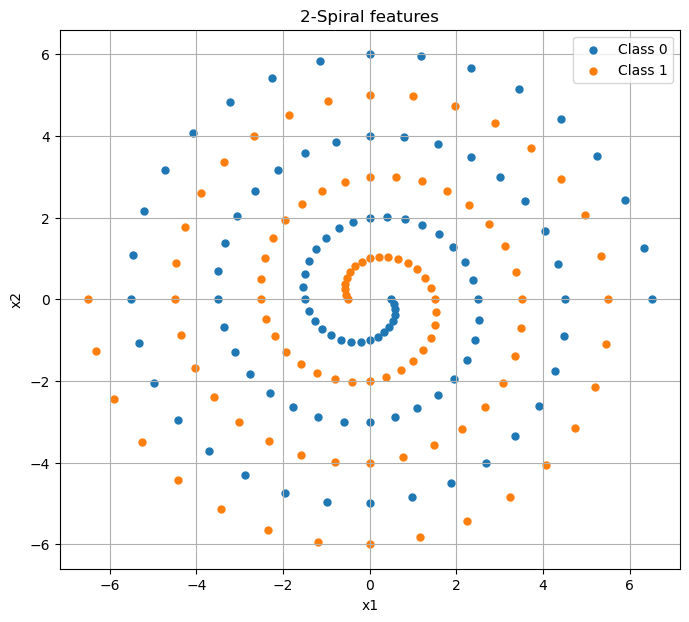

In [3]:
def plot_spirals(X, y, title="2-Spiral dataset", xlabel="x1", ylabel="x2"):
    plt.figure(figsize=(8, 7))
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"Class {cls}", s=25)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, zorder=0)
    plt.show()

plot_spirals(X, y, title="2-Spiral features", xlabel="x1", ylabel="x2")


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=15,
    stratify=y
)

print("Train inputs shape:", X_train.shape)
print("Train labels shape:", y_train.shape)
print("Test inputs shape:", X_test.shape)
print("Test labels shape:", y_test.shape)


Train inputs shape: (155, 2)
Train labels shape: (155,)
Test inputs shape: (39, 2)
Test labels shape: (39,)


In [5]:
svm = SVC(C=0.1, kernel="rbf", gamma=10)
svm.fit(X_train, y_train)

print("Model test accuracy (no scaling): {:.2f}%".format(svm.score(X_test, y_test) * 100))


Model test accuracy (no scaling): 48.72%


In [6]:
scores = cross_val_score(svm, X, y, cv=5)
print("CV fold accuracies:", scores)
print("Averaged {:.2f}% accuracy with a standard deviation of {:.2f}".format(scores.mean()*100, scores.std()))


CV fold accuracies: [0.48717949 0.48717949 0.48717949 0.48717949 0.15789474]
Averaged 42.13% accuracy with a standard deviation of 0.13


In [7]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])


In [8]:
parameters = {
    "svm__kernel": ["linear", "rbf"],
    "svm__C": [0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 50, 100],
    "svm__gamma": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

clf = GridSearchCV(
    estimator=pipe,
    param_grid=parameters,
    cv=5,
    n_jobs=-1
)

clf.fit(X_train, y_train)

print("Best parameters:", clf.best_params_)
print("Best CV score (on training split): {:.4f}".format(clf.best_score_))


Best parameters: {'svm__C': 5, 'svm__gamma': 10, 'svm__kernel': 'rbf'}
Best CV score (on training split): 0.7806


In [9]:
svm_final = clf.best_estimator_
svm_final.fit(X_train, y_train)

print("Final model test accuracy: {:.2f}%".format(svm_final.score(X_test, y_test) * 100))


Final model test accuracy: 76.92%


Confusion matrix:
 [[14  6]
 [ 3 16]]


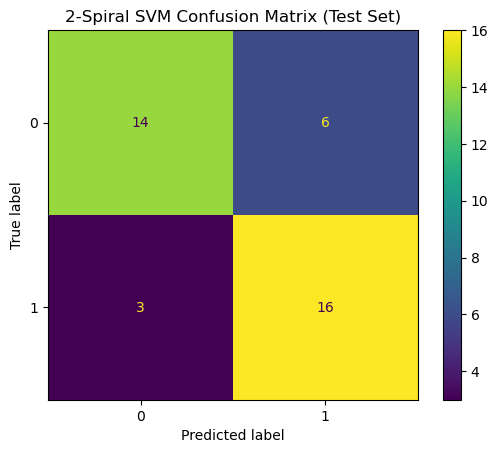


Classification report:
               precision    recall  f1-score   support

           0       0.82      0.70      0.76        20
           1       0.73      0.84      0.78        19

    accuracy                           0.77        39
   macro avg       0.78      0.77      0.77        39
weighted avg       0.78      0.77      0.77        39



In [10]:
y_pred_test = svm_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test)
print("Confusion matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("2-Spiral SVM Confusion Matrix (Test Set)")
plt.show()

print("\nClassification report:\n", classification_report(y_test, y_pred_test))